In [1]:
import matplotlib.pyplot as plt
plt.set_cmap('gray_r')

from tinygrad.helpers import Context, trange
from tinygrad import Tensor, Device , GlobalCounters
from tinygrad.nn.datasets import mnist

print(f"Default device: {Device.DEFAULT}")
X_train, Y_train, X_test, Y_test = mnist()
X_train = X_train.div(255.0)

print(X_train.shape, X_train.dtype, Y_train.shape, Y_train.dtype);

Default device: AMD
(60000, 1, 28, 28) dtypes.float (60000,) dtypes.uchar


<Figure size 640x480 with 0 Axes>

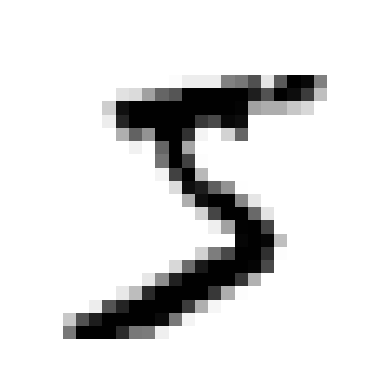

In [2]:
from afterhours_papers.helpers import show_image

show_image(X_train[0].reshape(28,28).numpy());

In [3]:
from tinygrad import nn
class conv_block:
    def __init__(self,
        in_channels: int,
        out_channels: int,
        kernel_size: int = 4,
        stride: int = 2,
        padding: int = 1):
        
        
        self.conv= nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding)
        self.norm = nn.BatchNorm2d(out_channels)
    
    def __call__(self,x:Tensor) -> Tensor:
        x = self.conv(x)
        x = self.norm(x)
        return x.sigmoid()


In [4]:
conv = conv_block(in_channels=1, out_channels=32, kernel_size=4, stride=2, padding=1)
img_in = X_train[0].unsqueeze(0)
output = conv(img_in)
print("Output shape:", output.shape)  # Expected: (1, 32, 14, 14) due to stride=2


Output shape: (1, 32, 14, 14)


In [5]:
class Encoder:
    def __init__(self, in_channels):
        self.conv1 = conv_block(in_channels, 128)
        self.conv2 = conv_block(128,256)
        self.conv3 = conv_block(256,512)
        self.conv4 = conv_block(512,1024)
        self.linear = nn.Linear(1024,16)
    
    def __call__(self, x: Tensor) -> Tensor:    # (bs, 1, 28 , 28)
        x = self.conv1(x)                       # (bs, 128, 14 ,14)
        x = self.conv2(x)                       # (bs, 256, 7 ,7)
        x = self.conv3(x)                       # (bs, 512, 3 ,3)
        x = self.conv4(x)                       # (bs, 1024, 1 ,1)
        x = self.linear(x.flatten(start_dim=1)) # (bs, 16)
        return x 



In [6]:
encoder = Encoder(1)
print(encoder(img_in).shape)

(1, 16)


Now lets try batch

In [7]:
BATCH_SIZE = 64
batch = X_train[0:64]

out = encoder(batch)
print(out.shape)

(64, 16)


# Now up

In [8]:
class conv_transpose_block:
    def __init__(self,
        in_channels: int,
        out_channels: int,
        kernel_size: int = 3,
        stride: int = 2,
        padding: int = 1,
        output_padding: int = 0,
        with_act: bool = True):
        self.t_conv = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size,
            stride,
            padding,
            output_padding
        )
        if with_act:
            self.norm = nn.BatchNorm2d(out_channels)
 
    def __call__(self, x: Tensor) -> Tensor:
        x = self.t_conv(x)
        if hasattr(self, 'norm'):
            x = self.norm(x)
            return x.relu()
        return x

In [9]:
class Decoder():
    def __init__(self, out_channels: int):
        self.linear = nn.Linear(16, 1024 * 4 * 4)
        self.t_conv1 = conv_transpose_block(1024, 512)
        self.t_conv2 = conv_transpose_block(512, 256, output_padding=1)
        self.t_conv3 = conv_transpose_block(256, out_channels, output_padding=1, with_act=False) 
        # No normalization on last t_conv and no relu as well so we can pass values to sigmoid

    def __call__(self, x:Tensor) -> Tensor:
        bs = x.shape[0]
        x = self.linear(x)              #(bs, 1024 *4 *4)
        x = x.reshape((bs, 1024, 4, 4)) #(bs, 1024, 4, 4)
        x = self.t_conv1(x)             #(bs, 512, 7, 7)
        x = self.t_conv2(x)             #(bs, 256, 14, 14)
        x = self.t_conv3(x)             #(bs, out_channels, 28, 28)
        return x.sigmoid()              # Added sigmoid to squeeze values between (0,1)

In [10]:
BATCH_SIZE = 64
batch = X_train[0:BATCH_SIZE]
encoder = Encoder(1)

encoder_out = encoder(batch)
print(encoder_out.shape)

decoder = Decoder(batch.shape[0])
decoded_out = decoder(encoder_out)
print(decoded_out.shape)

(64, 16)
(64, 64, 28, 28)


# Training

In [11]:
class AutoEncoder():
    def __init__(self, in_channels):
        self.encoder = Encoder(in_channels)
        self.decoder = Decoder(in_channels)
    
    def encode(self, x: Tensor) -> Tensor:
        return self.encoder(x)
    
    def decode(self, x:Tensor) -> Tensor:
        return self.decoder(x)
    
    def __call__(self, x:Tensor) -> Tensor:
        return self.decode(self.encode(x))

In [12]:
samples = Tensor.randint(BATCH_SIZE, high= X_train.shape[0]);samples.numpy()

array([40885, 18821, 37060, 18872, 48683, 55081, 44013,  6163, 18383,
        4988, 45661,  7340, 43210, 59363,  5254, 16735, 40061,   361,
       50202, 45322, 42036,  1020, 56543, 39177, 59509,  4744,  1488,
       52330, 27117, 32867, 53753, 22904, 16298,  3136, 36351, 15862,
       26794, 14416, 20124, 35531, 20879, 28929, 49994, 46231, 42455,
       16070, 54232, 26459, 43349, 45416, 53919, 46047, 25894,  2421,
        7259, 57169, 35265, 10485, 16594, 27178, 49107,  5341, 26175,
        1439], dtype=int32)

In [16]:
from tinygrad import TinyJit
# Training loop with MSE function

model = AutoEncoder(1)
epochs = 10
lr = 1e-4
optim = nn.optim.AdamW(nn.state.get_parameters(model), lr=lr, eps=1e-5)

losses = []

def mean_squared_error(self, Y: Tensor, reduction: str = "mean") -> Tensor:
    return self.sub(Y).pow(2)._do_reduction(reduction)

Tensor.mean_squared_error = mean_squared_error  # type: ignore

@Tensor.train()
@TinyJit
def train_step():
    optim.zero_grad()
    samples = Tensor.randint(BATCH_SIZE, high=X_train.shape[0])
    X = X_train[samples]
    preds = model(X)
    loss = preds.mean_squared_error(X)
    loss.backward()
    optim.step()
    return loss.realize()

In [17]:
from tinygrad import GlobalCounters
from tinygrad.helpers import trange, Context
# Calculate step_size
step_size = len(X_train) // BATCH_SIZE
epochs = 10

if __name__ == "__main__":
# Modified training loop to use trange
    with Context(BEAM=2):
        for step in (t := trange(epochs * step_size)):
            GlobalCounters.reset()
            loss = train_step()
            loss_item = loss.item()
            losses.append(loss_item)
            t.set_description(f"loss: {loss_item:6.4f}")


loss: 0.0098: 100%|█████████████████████████| 9370/9370 [02:30<00:00, 62.39it/s]


9370 0.006729842163622379


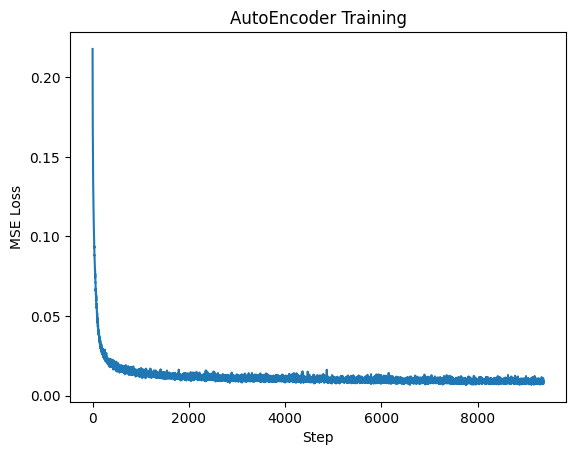

In [18]:
print(len(losses), min(losses))
# --- Plotting ---
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.title("AutoEncoder Training")
plt.show()

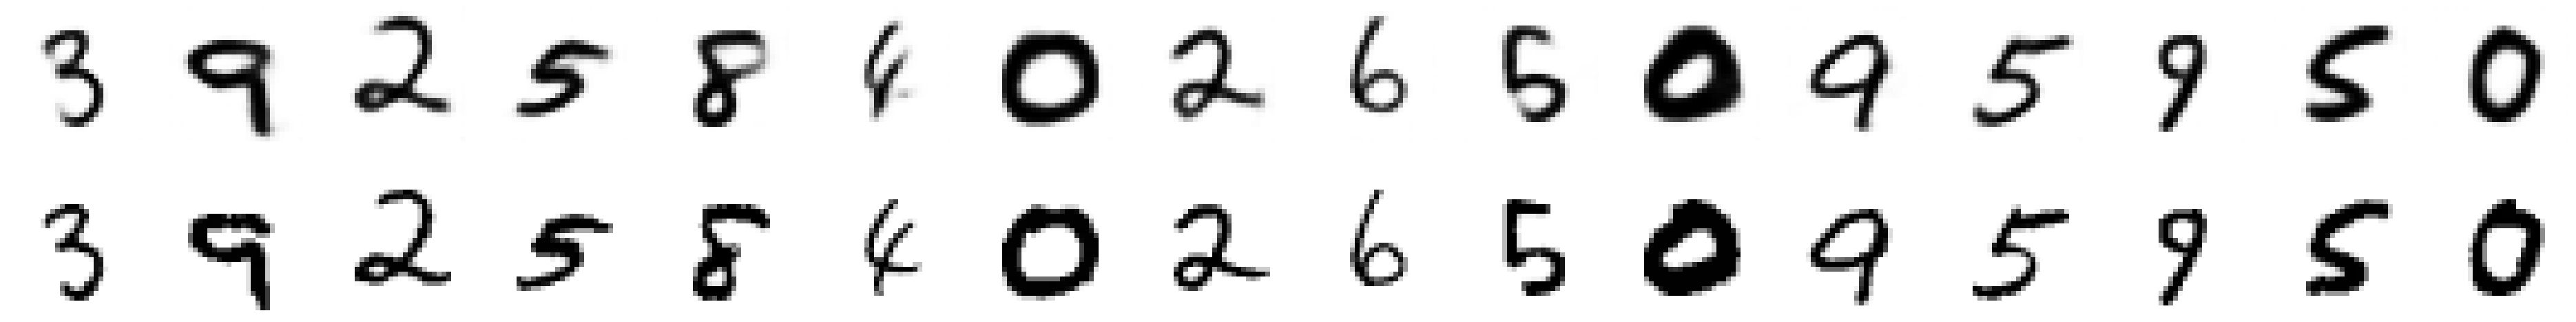

In [19]:
from afterhours_papers.helpers import show_images
# Example usage
sample_size = 16
samples = Tensor.randint(sample_size, high=X_train.shape[0])
batch = X_train[samples]

out = model(batch)
batch_vs_preds = out.cat(batch, dim=0)

images = batch_vs_preds.reshape(sample_size*2 ,28 ,28).numpy()
# Display using the show_images function
show_images(
    images,
    nrows=2,
    ncols=sample_size,
);

# Let's use BCELoss for sharper images.

In [20]:
t = Tensor([0.1, 0.9, 0.2])
Y = Tensor([0, 1, 0])
print(t.binary_crossentropy(Y).item())

0.14462155103683472


In [21]:
t = Tensor([-1, 2, -3])
Y = Tensor([0, 1, 0])
print(t.binary_crossentropy_logits(Y).item())

0.16292569041252136


Since our decoder now includes a sigmoid activation at the output layer, we should use `BCELoss` instead of BCELoss with logits to avoid applying sigmoid twice.

Let's retrain.

In [30]:
from tinygrad import TinyJit
# Training loop with MSE function

model = AutoEncoder(1)
epochs = 10
lr = 1e-4
optim = nn.optim.AdamW(nn.state.get_parameters(model), lr=lr, eps=1e-5)

losses = []

@Tensor.train()
@TinyJit
def train_step():
    optim.zero_grad()
    samples = Tensor.randint(BATCH_SIZE, high=X_train.shape[0])
    X = X_train[samples]
    preds = model(X)
    loss = preds.binary_crossentropy(X)
    loss.backward()
    optim.step()
    return loss.realize()

In [31]:
from tinygrad import GlobalCounters
from tinygrad.helpers import trange, Context
# Calculate step_size
step_size = len(X_train) // BATCH_SIZE
epochs = 10

if __name__ == "__main__":
# Modified training loop to use trange
    with Context(BEAM=2):
        for step in (t := trange(epochs * step_size)):
            GlobalCounters.reset()
            loss = train_step()
            loss_item = loss.item()
            losses.append(loss_item)
            t.set_description(f"loss: {loss_item:6.4f}")


loss: 0.0853: 100%|█████████████████████████| 9370/9370 [02:22<00:00, 65.66it/s]


9370 0.07713894546031952


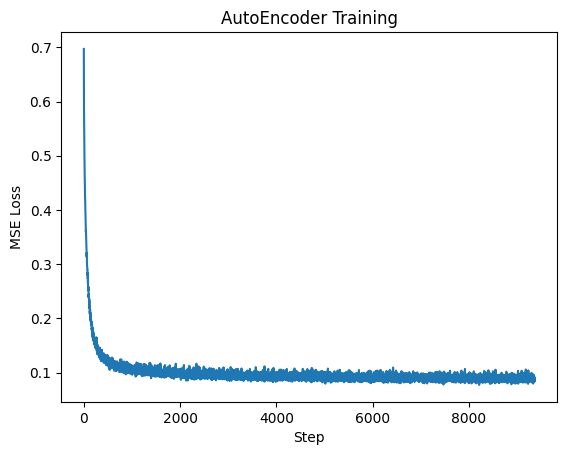

In [32]:
print(len(losses), min(losses))
# --- Plotting ---
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.title("AutoEncoder Training")
plt.show()

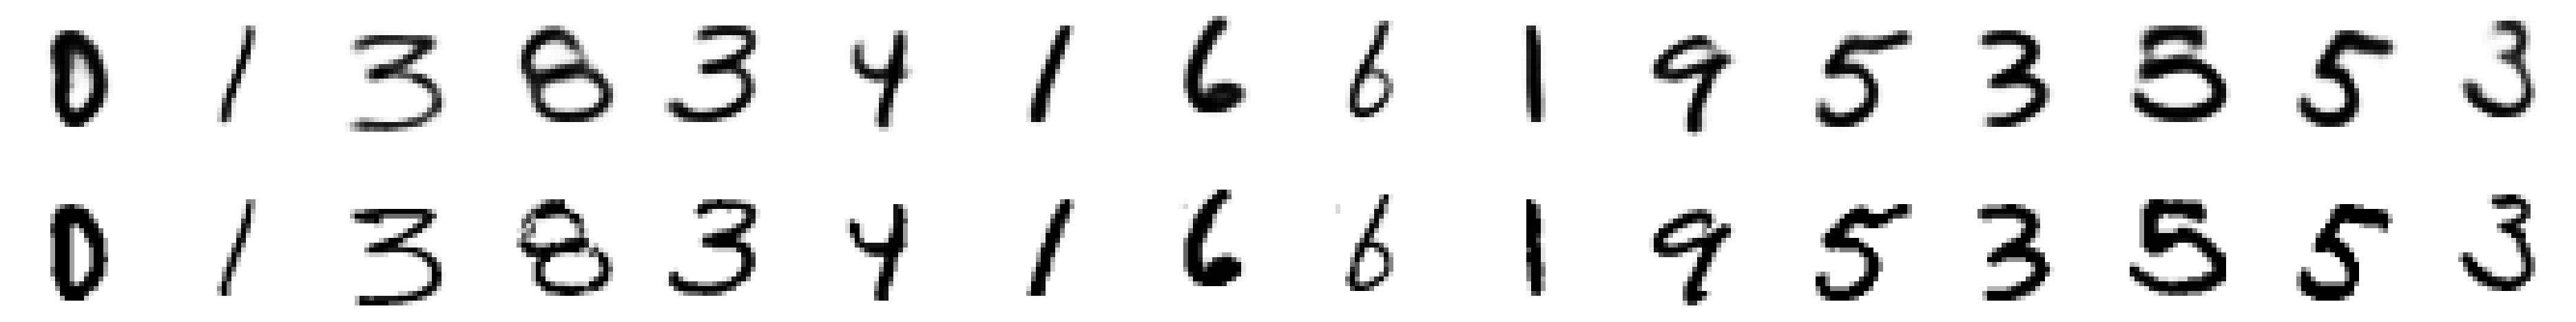

In [33]:
from afterhours_papers.helpers import show_images
# Example usage
sample_size = 16
samples = Tensor.randint(sample_size, high=X_train.shape[0])
batch = X_train[samples]

out = model(batch)
batch_vs_preds = out.cat(batch, dim=0)

images = batch_vs_preds.reshape(sample_size*2 ,28 ,28).numpy()
# Display using the show_images function
show_images(
    images,
    nrows=2,
    ncols=sample_size,
);